# Patient Segmentation using K-Means and Hierarchical Clustering
* Yusuf Imantaka Bastari
* Muhammad Javier
* Khrisna Dwi Haryanto


## Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('patient_segmentation_dataset.csv')
pd.set_option('display.max_columns', None)
df.dropna(inplace=True)

In [3]:
df.head()

,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0


In [4]:
df.dtypes

PatientID                  object
Age                         int64
Gender                     object
State                      object
City                       object
Height_cm                   int64
Weight_kg                   int64
BMI                       float64
Insurance_Type             object
Primary_Condition          object
Num_Chronic_Conditions      int64
Annual_Visits               int64
Avg_Billing_Amount        float64
Last_Visit_Date            object
Days_Since_Last_Visit       int64
Preventive_Care_Flag        int64
dtype: object

In [5]:
# Drop Unnecesary Columns

df_new = df.drop(columns=['PatientID'])

# Encode Categorical Variables

def encode_categorical(df):
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
    df['State'] = df['State'].map(df['State'].value_counts(normalize=True).to_dict())
    df['City'] = df['City'].map(df['City'].value_counts(normalize=True).to_dict())
    df['Insurance_Type'] = df['Insurance_Type'].map(df['Insurance_Type'].value_counts(normalize=True).to_dict())
    df['Primary_Condition'] = df['Primary_Condition'].map(df['Primary_Condition'].value_counts(normalize=True).to_dict())

    return df

encoded_df = encode_categorical(df_new)

In [6]:
encoded_df.head()

,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,64,0,0.106312,0.50299,151,115,50.4,0.257143,0.108306,3,7,2995.0,2025-07-18,186,0
1,59,0,0.100997,0.50299,189,68,19.0,0.534884,0.106312,1,8,1209.0,2025-12-12,39,0
2,58,1,0.097674,0.50299,156,91,37.4,0.257143,0.106312,1,4,999.0,2025-09-16,126,0
3,43,1,0.106312,0.50299,152,92,39.8,0.534884,0.139535,1,6,5638.5,2025-04-09,286,1
4,53,1,0.102326,0.50299,167,51,18.3,0.207973,0.106312,1,4,5796.0,2025-03-07,319,0


In [7]:
# Fix Date Time Column

encoded_df['Last_Visit_Date'] = pd.to_datetime(encoded_df['Last_Visit_Date'])

# Extract features from date time column

encoded_df['Last_Visit_Year'] = encoded_df['Last_Visit_Date'].dt.year
encoded_df['Last_Visit_Month'] = encoded_df['Last_Visit_Date'].dt.month
encoded_df['Last_Visit_Day'] = encoded_df['Last_Visit_Date'].dt.day

encoded_df = encoded_df.drop(columns=['Last_Visit_Date'])

In [8]:
encoded_df.isnull().sum()

Age                       0
Gender                    0
State                     0
City                      0
Height_cm                 0
Weight_kg                 0
BMI                       0
Insurance_Type            0
Primary_Condition         0
Num_Chronic_Conditions    0
Annual_Visits             0
Avg_Billing_Amount        0
Days_Since_Last_Visit     0
Preventive_Care_Flag      0
Last_Visit_Year           0
Last_Visit_Month          0
Last_Visit_Day            0
dtype: int64

# K-Means Clustering

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(encoded_df)

In [10]:
# Elbow method, find the optimal number of clusters

wcss = []

k_range = range(2, 45)

for k in k_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )
    km.fit(scaled_df)
    wcss.append(km.inertia_)

/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:2

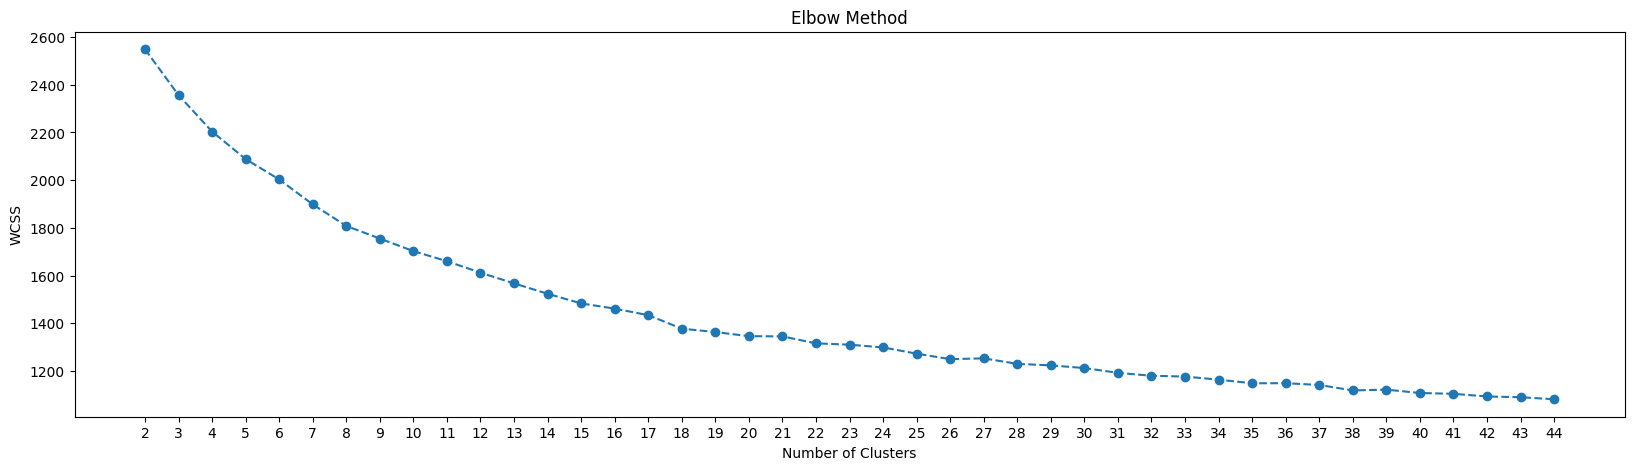

In [11]:
plt.figure(figsize=(20, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.xticks(k_range)
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:2

Best k by Silhouette: 18
Best Silhouette Score: 0.1691675299898112


/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


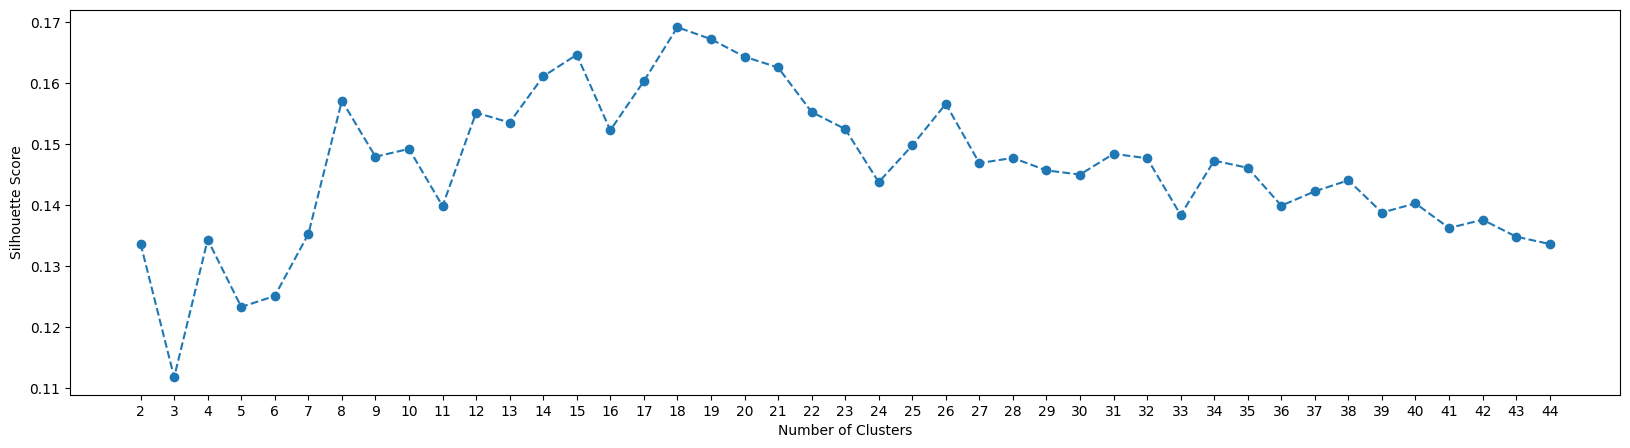

In [12]:
# Silhouette scored

from sklearn.metrics import silhouette_score
import numpy as np

sil_scores = []

for k in k_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )

    labels_tmp = km.fit_predict(scaled_df)
    sil_scores.append(silhouette_score(scaled_df, labels_tmp))

plt.figure(figsize=(20, 5))
plt.plot(k_range, sil_scores, marker='o', linestyle='--')
plt.xticks(k_range)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

best_k = k_range[np.argmax(sil_scores)]
kmeans_score = max(sil_scores)  # Store the best silhouette score
print(f"Best k by Silhouette: {best_k}")
print(f"Best Silhouette Score: {kmeans_score}")

In [13]:
kmeans = KMeans(
    n_clusters=best_k,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

kmeans.fit(scaled_df)

labels = kmeans.predict(scaled_df)

/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:2

In [14]:
df['Cluster_Kmeans'] = labels

In [15]:
cluster_profile_kmeans = df.groupby('Cluster_Kmeans').mean(numeric_only=True)
cluster_profile_kmeans

,Age,Height_cm,Weight_kg,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag
Cluster_Kmeans,,,,,,,,,
0,50.380952,164.464286,81.095238,30.267857,1.119048,6.583333,3955.648810,214.309524,0.000000
1,69.680000,161.700000,88.000000,33.922000,2.740000,6.160000,5857.740000,187.980000,1.000000
2,63.302083,163.229167,82.947917,31.709375,1.697917,6.145833,5063.875000,190.854167,0.000000
3,61.025641,171.128205,81.923077,28.324359,1.666667,6.076923,4394.115385,181.282051,1.000000
4,62.892473,173.236559,85.225806,28.917204,1.645161,5.946237,4117.247312,186.129032,0.000000
5,51.894737,163.026316,86.776316,33.073684,1.065789,7.092105,3913.921053,185.250000,1.000000
6,50.939024,162.085366,86.646341,33.490244,1.195122,6.695122,4042.286585,189.243902,1.000000
7,50.263158,171.663158,85.547368,29.572632,1.178947,6.610526,4178.626316,170.052632,0.000000
8,51.091954,173.735632,88.183908,29.818391,1.137931,6.229885,4056.333333,186.137931,0.000000


In [16]:
cluster_profile_kmeans.to_csv('cluster_profile_kmeans.csv', index=False)

/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


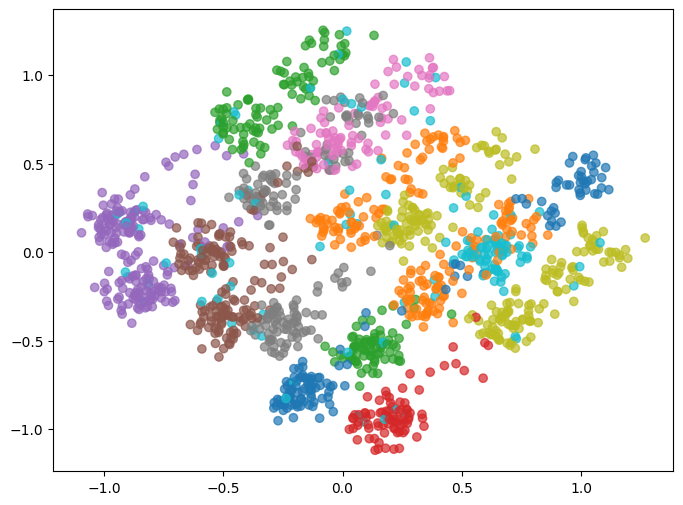

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='tab10', alpha=0.7)

/var/folders/x1/51z6f1rj1hsgx96jjn1v09880000gn/T/ipykernel_22752/1471533899.py:16: UserWarning: Adding colorbar to a different Figure <Figure size 800x600 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label='Cluster')


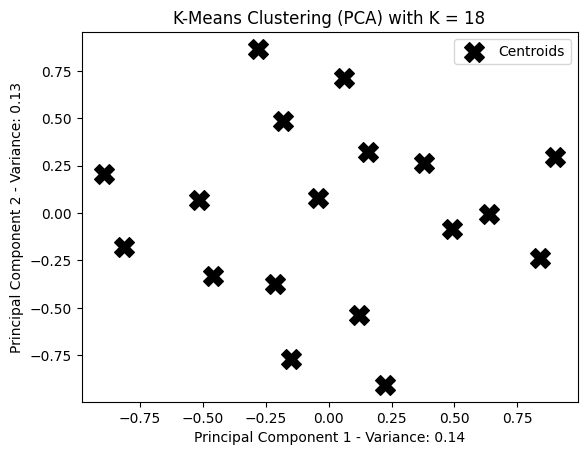

In [18]:
# Plot centroids in PCA space

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title(f'K-Means Clustering (PCA) with K = {best_k}')
plt.xlabel(f'Principal Component 1 - Variance: {pca.explained_variance_ratio_[0]:.2f}')
plt.ylabel(f'Principal Component 2 - Variance: {pca.explained_variance_ratio_[1]:.2f}')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.show()

# Hierarchical (Agglomerative) Clustering

In [19]:
# Import library
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(
    n_clusters=best_k,
    distance_threshold=None,
    metric='euclidean',
    linkage='ward',
    compute_full_tree='auto',
    compute_distances=False,
    memory=None,
    connectivity=None,
)

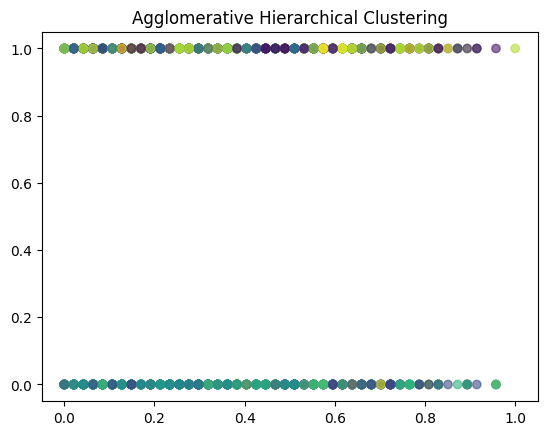

In [20]:
clusters_agg_labels = agg_clustering.fit_predict(scaled_df)
plt.scatter(scaled_df[:, 0], scaled_df[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.title("Agglomerative Hierarchical Clustering")
plt.show()

/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encounter

Best k by Silhouette: 19


/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


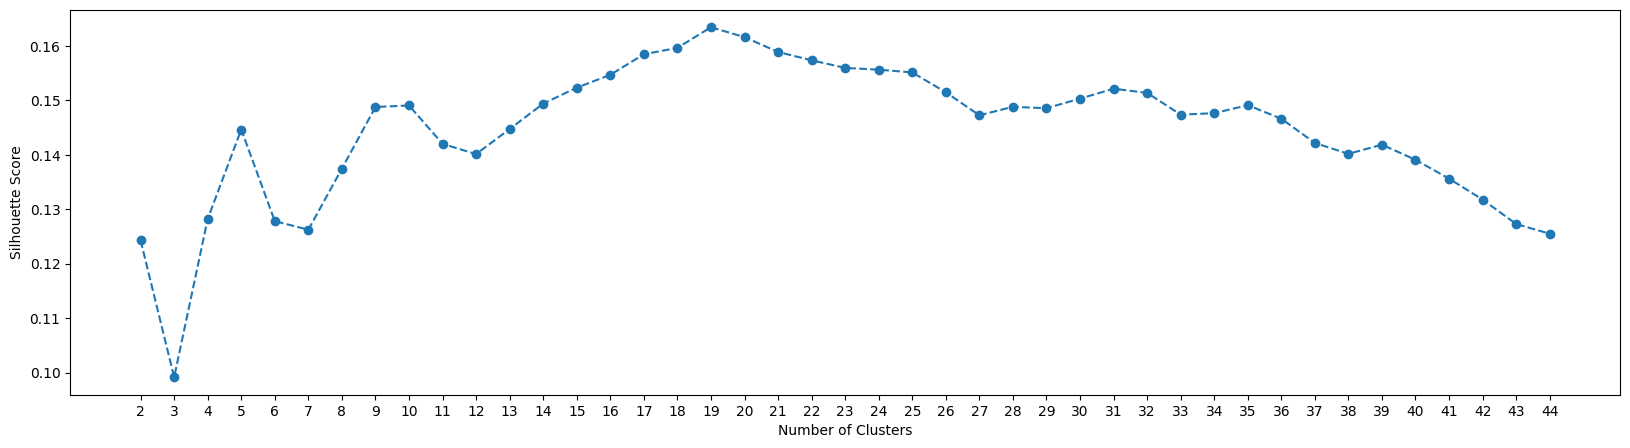

In [21]:
# Silhoutee scored

from sklearn.metrics import silhouette_score
import numpy as np

sil_scores = []

for k in k_range:
    agg_clustering = AgglomerativeClustering(
        n_clusters=k,
        distance_threshold=None,
        metric='euclidean',
        linkage='ward',
        compute_full_tree='auto',
        compute_distances=False,
        memory=None,
        connectivity=None,
    )

    cluster_agg_labels = agg_clustering.fit_predict(scaled_df)
    sil_scores.append(silhouette_score(scaled_df, cluster_agg_labels))

plt.figure(figsize=(20, 5))
plt.plot(k_range, sil_scores, marker='o', linestyle='--')
plt.xticks(k_range)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

best_k = k_range[np.argmax(sil_scores)]
print(f"Best k by Silhouette: {best_k}")

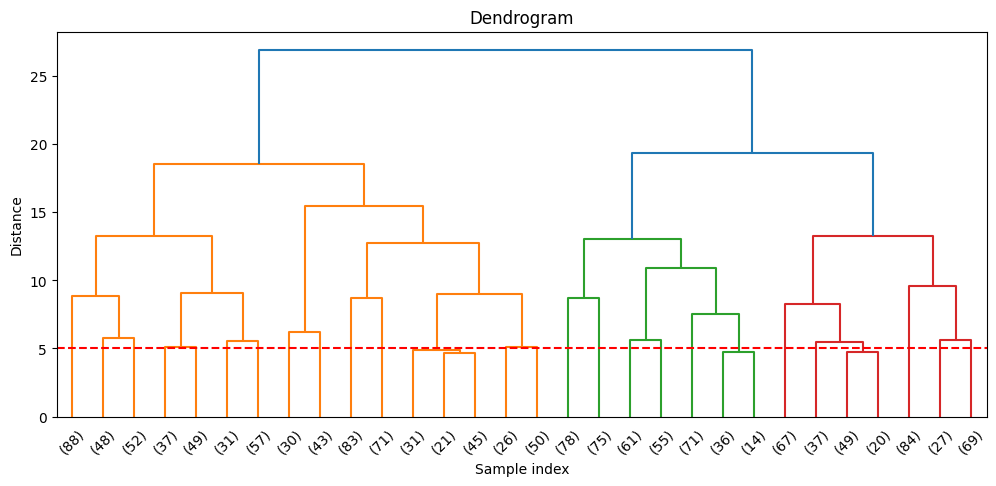

In [22]:
# Plotting dendogram
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(scaled_df, method='ward', metric='euclidean')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30)  
plt.title('Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.axhline(y=5, color='r', linestyle='--')  
plt.show()

# Low Silhouette Score Analysis

In [23]:
from sklearn.decomposition import PCA
import numpy as np

# Check how much variance 2 and 3 components capture
pca_check = PCA()
pca_check.fit(scaled_df)
cumvar = np.cumsum(pca_check.explained_variance_ratio_)


for i in range(len(cumvar)):
    print(f"{i+1} components: {cumvar[i]:.2%} variance")


1 components: 14.48% variance
2 components: 27.75% variance
3 components: 40.30% variance
4 components: 52.65% variance
5 components: 60.66% variance
6 components: 66.78% variance
7 components: 72.69% variance
8 components: 77.71% variance
9 components: 82.72% variance
10 components: 87.16% variance
11 components: 90.66% variance
12 components: 93.91% variance
13 components: 96.74% variance
14 components: 98.68% variance
15 components: 99.97% variance
16 components: 100.00% variance
17 components: 100.00% variance


In [24]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

linkages = ['ward', 'complete', 'average', 'single']
results = []

for linkage in linkages:
    model = AgglomerativeClustering(n_clusters=19, linkage=linkage)
    labels = model.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    
    results.append((linkage, score))

import pandas as pd
pd.DataFrame(results, columns=["Linkage", "Silhouette Score"])

/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encounter

,Linkage,Silhouette Score
0,ward,0.163434
1,complete,0.088467
2,average,0.104486
3,single,-0.065977


In [25]:
# FINAL MODEL CHOICE
final_linkage = 'ward'

model = AgglomerativeClustering(n_clusters=best_k, linkage=final_linkage)
df['Cluster_HC'] = model.fit_predict(scaled_df)
df['Cluster_HC'].value_counts().sort_index()

Cluster_HC
0     100
1      96
2     106
3      88
4     116
5      86
6      76
7      43
8      50
9      71
10     84
11     75
12     97
13     88
14     83
15     78
16     67
17     71
18     30
Name: count, dtype: int64

In [26]:
cluster_profile = df.groupby('Cluster_HC').mean(numeric_only=True)
cluster_profile

,Age,Height_cm,Weight_kg,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag,Cluster_Kmeans
Cluster_HC,,,,,,,,,,
0,62.020000,173.950000,84.270000,28.385000,1.600000,6.010000,4080.500000,200.220000,0.000000,4.240000
1,63.302083,163.229167,82.947917,31.709375,1.697917,6.145833,5063.875000,190.854167,0.000000,2.000000
2,60.575472,162.603774,87.735849,33.571698,1.490566,7.094340,5110.702830,190.490566,0.000000,13.915094
3,61.954545,170.897727,89.727273,31.252273,1.670455,6.022727,4842.051136,173.727273,0.000000,11.954545
4,62.801724,164.017241,84.112069,31.673276,1.741379,6.836207,4713.844828,202.327586,1.000000,14.689655
5,51.209302,173.488372,87.941860,29.831395,1.139535,6.279070,4047.982558,185.151163,0.000000,8.000000
6,60.921053,170.736842,81.473684,28.309211,1.631579,6.026316,4446.855263,180.289474,1.000000,3.000000
7,57.581395,173.744186,89.813953,30.425581,1.558140,6.604651,4430.604651,10.953488,0.511628,16.000000
8,68.400000,163.960000,83.900000,31.402000,2.900000,5.760000,6265.060000,194.300000,1.000000,2.680000


In [27]:
cluster_profile.to_csv('cluster_profile_silhoutte.csv', index=False)

In [28]:
pd.crosstab(df['Cluster_HC'], df['Insurance_Type'], normalize='index')

Insurance_Type,Medicaid,Medicare,Private
Cluster_HC,,,
0,0.040000,0.920000,0.040000
1,0.000000,1.000000,0.000000
2,0.047170,0.915094,0.037736
3,0.000000,0.988636,0.011364
4,0.008621,0.965517,0.025862
5,0.383721,0.000000,0.616279
6,0.000000,1.000000,0.000000
7,0.186047,0.581395,0.232558
8,0.040000,0.680000,0.280000


In [29]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'State', 'City', 'Height_cm', 'Weight_kg',
       'BMI', 'Insurance_Type', 'Primary_Condition', 'Num_Chronic_Conditions',
       'Annual_Visits', 'Avg_Billing_Amount', 'Last_Visit_Date',
       'Days_Since_Last_Visit', 'Preventive_Care_Flag', 'Cluster_Kmeans',
       'Cluster_HC'],
      dtype='object')

In [30]:
pd.crosstab(df['Cluster_HC'], df['Gender'], normalize='index')

Gender,Female,Male
Cluster_HC,,
0,0.00,1.00
1,1.00,0.00
2,1.00,0.00
3,0.00,1.00
4,1.00,0.00
5,0.00,1.00
6,0.00,1.00
7,0.00,1.00
8,0.84,0.16


/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/muhajav/Documents/Machine Learning/final_project/patient-segmentation/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


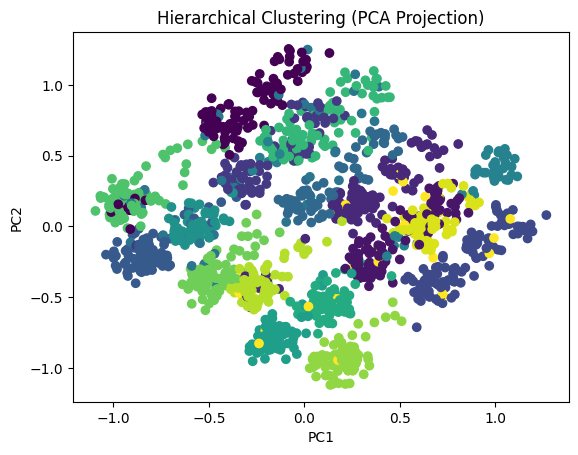

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster_HC'], cmap='viridis')
plt.title("Hierarchical Clustering (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

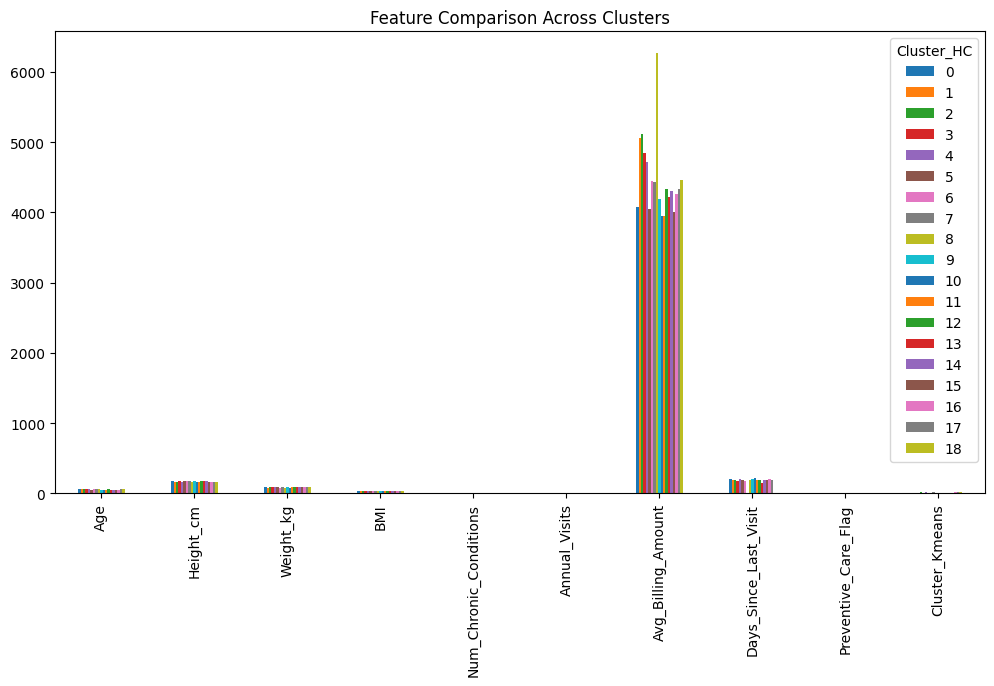

In [32]:
cluster_profile.T.plot(kind='bar', figsize=(12,6))
plt.title("Feature Comparison Across Clusters")
plt.show()

In [33]:
comparison = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical"],
    "Silhouette Score": [kmeans_score, 0.163],
    "Interpretability": ["Medium", "High"],
    "Structure Insight": ["Low", "High"]
})

comparison

,Method,Silhouette Score,Interpretability,Structure Insight
0,K-Means,0.169168,Medium,Low
1,Hierarchical,0.163000,High,High
